<a>
  <img src="../images/depth_sensors.png" alt="Pinhole camera" width="980" style="background-color: white;padding: 10px;">
</a>

- Stereo-Kamera: Zwei Kameras, um 3D-Tiefeninformation zu gewinnen
- Time-of-Flight (ToF): Misst direkt die Laufzeit des Lichts → Tiefenbild
- Structured Light: Projiziert Muster zur Tiefenmessung

# Passive Stereo

<a>
  <img src="../images/triangulation.png" alt="Pinhole camera" width="1000">
</a>

$u_l - u_r$ is the disparity. This is the difference int the u-coordinate of the same scene point in the two images - left and right.

bzw. 

$d= \frac{b\cdot f}{z}$

<a>
  <img src="../images/epipolar_constraint.png" alt="Pinhole camera" width="500">
</a>

### Fundamental Matrix F

The Fundamental Matrix

$$
    0=
    \begin{bmatrix}
    u_l & v_l & 1 \\
    \end{bmatrix} 
    \cdot
    \underline{\underline{F}}
    \cdot
    \begin{bmatrix}
    u_r\\
    v_r\\
    1\\
    \end{bmatrix}
$$



$$
F=A^{-T}\cdot 
\begin{bmatrix}
0 & -t_z & t_y\\
t_z & 0 & -t_x\\
-t_y & t_x & 0\\
\end{bmatrix} 
\cdot

    \begin{bmatrix}
    r_{11} & r_{12} & r_{13}\\
    r_{21} & r_{22} & r_{23}\\
    r_{31} & r_{32} & r_{33}\\
    \end{bmatrix}

\cdot A^{-1}
$$

$$
\mathbf{F} = \mathbf{A}^{-T} \cdot \mathbf{E} \cdot \mathbf{A}^{-1}
$$

### Essential Matrix

The Essential Matrix is needed to calibrate an uncalibrated stereo system. This means, with E we find out how one camera is rotated and translated in respect to the other one.

1. write the epipolar constraint **$x_l \cdot (t \times x_l)=0$** in crossproduct form and in matrix form 

$$
    \begin{bmatrix}
    x_l & y_l & z_l \\
    \end{bmatrix} 
    \cdot
    \begin{bmatrix}
    t_y \cdot z_l & - t_z \cdot y_l\\
    t_z \cdot x_l & - t_x \cdot z_l\\
    t_x \cdot y_l & - t_y \cdot x_l \\
    \end{bmatrix}
    = 0 = 
    \begin{bmatrix}
    x_l & y_l & z_l \\
    \end{bmatrix} 
    \cdot
    \begin{bmatrix}
    0 & -t_z & t_y\\
    t_z & 0 & -t_x\\
    -t_y & t_x & 0\\
    \end{bmatrix}
    \cdot
    \begin{bmatrix}
    x_l\\
    y_l\\
    z_l\\
    \end{bmatrix}\tag{1}
$$

2. consider the correlation between the scene point by the left and the rigth camera **$x_l = R \cdot x_r + t$**   

$$
    \begin{bmatrix}
    x_l\\
    y_l\\
    z_l\\
    \end{bmatrix}
    = 
    \begin{bmatrix}
    r_{11} & r_{12} & r_{13}\\
    r_{21} & r_{22} & r_{23}\\
    r_{31} & r_{32} & r_{33}\\
    \end{bmatrix}
    \cdot
    \begin{bmatrix}
    x_r\\
    y_r\\
    z_r\\
    \end{bmatrix}
    + 
    \begin{bmatrix}
    t_x\\
    t_y\\
    t_z\\
    \end{bmatrix}\tag{2}
$$

3. Gleichung $(2)$ in $(1)$ einsetzen

$$
    0=
    \begin{bmatrix}
    x_l & y_l & z_l \\
    \end{bmatrix} 
    \cdot
    \begin{bmatrix}
    0 & -t_z & t_y\\
    t_z & 0 & -t_x\\
    -t_y & t_x & 0\\
    \end{bmatrix}
    \cdot
    \left(
    \begin{bmatrix}
    r_{11} & r_{12} & r_{13}\\
    r_{21} & r_{22} & r_{23}\\
    r_{31} & r_{32} & r_{33}\\
    \end{bmatrix}
    \cdot
    \begin{bmatrix}
    x_r\\
    y_r\\
    z_r\\
    \end{bmatrix}
    + 
    \begin{bmatrix}
    t_x\\
    t_y\\
    t_z\\
    \end{bmatrix}
    \right)
    \tag{3}
$$

Zieht man jetzt die Translationsmatrix in die Klammer, kürzt sich $t\times t$ und es bleibt:

$$
    0=
    \begin{bmatrix}
    x_l & y_l & z_l \\
    \end{bmatrix} 
    \cdot
    \left(
    \begin{bmatrix}
    0 & -t_z & t_y\\
    t_z & 0 & -t_x\\
    -t_y & t_x & 0\\
    \end{bmatrix}
    \cdot
    \begin{bmatrix}
    r_{11} & r_{12} & r_{13}\\
    r_{21} & r_{22} & r_{23}\\
    r_{31} & r_{32} & r_{33}\\
    \end{bmatrix}
    \cdot
    \begin{bmatrix}
    x_r\\
    y_r\\
    z_r\\
    \end{bmatrix}
    \right)
    \tag{4}
$$

$$
    0=
    \begin{bmatrix}
    x_l & y_l & z_l \\
    \end{bmatrix} 
    \cdot
    \underline{\underline{E}}
    \cdot
    \begin{bmatrix}
    x_r\\
    y_r\\
    z_r\\
    \end{bmatrix}
    \tag{4.1}
$$

4. Aus Gleichung $(4)$ ergibt sich die Essential Matrix $E$ zu:

$$
    \underline{\underline{E}}=
    \begin{bmatrix}
    0 & -t_z & t_y\\
    t_z & 0 & -t_x\\
    -t_y & t_x & 0\\
    \end{bmatrix}
    \cdot
    \begin{bmatrix}
    r_{11} & r_{12} & r_{13}\\
    r_{21} & r_{22} & r_{23}\\
    r_{31} & r_{32} & r_{33}\\
    \end{bmatrix}
    \tag{5}
$$

In [4]:
import cv2
import numpy as np

# Simulierte Punktkorrespondenzen (je 8+ Punkte notwendig)
pts1 = np.array([
    [100, 150], [120, 180], [130, 200], [150, 220],
    [170, 240], [190, 260], [210, 280], [230, 300]
], dtype=np.float32)

# Zweites Bild: leicht verschobene Punkte
pts2 = pts1 + np.random.normal(0, 1, pts1.shape) + [5, 0]

# Kamera-Matrix (für Essential-Matrix): Beispielwerte
K = np.array([
    [800, 0, 320],
    [0, 800, 240],
    [0,   0,   1]
], dtype=np.float64)

# Fundamental Matrix aus Bildpunkten schätzen
F, mask_F = cv2.findFundamentalMat(pts1, pts2, method=cv2.FM_8POINT)

# Essential Matrix aus Bildpunkten und Kameramatrix
E, mask_E = cv2.findEssentialMat(pts1, pts2, cameraMatrix=K, method=cv2.RANSAC, prob=0.999, threshold=1.0)

# Pose aus Essential-Matrix extrahieren (Rotation, Translation)
_, R, t, mask_pose = cv2.recoverPose(E, pts1, pts2, K)

# Ergebnis anzeigen
print("Fundamental Matrix F:\n", F)
print("\nEssential Matrix E:\n", E)
print("\nRotation R:\n", R)
print("\nTranslation t:\n", t)

Fundamental Matrix F:
 [[-7.80231662e-04  7.80231662e-04 -5.46162163e-02]
 [ 4.64662322e-04 -4.64662322e-04  3.25263626e-02]
 [ 1.42857143e-02 -1.42857143e-02  1.00000000e+00]]

Essential Matrix E:
 [[-0.01110625 -0.68150748  0.12199686]
 [ 0.6803517  -0.01070814  0.14737433]
 [-0.12580748 -0.14142127 -0.00108195]]

Rotation R:
 [[-0.91645251 -0.05599006 -0.3962069 ]
 [-0.08717578 -0.9384408   0.33425925]
 [-0.39053192  0.34087237  0.85515545]]

Translation t:
 [[-0.20268678]
 [ 0.17485824]
 [ 0.9635054 ]]


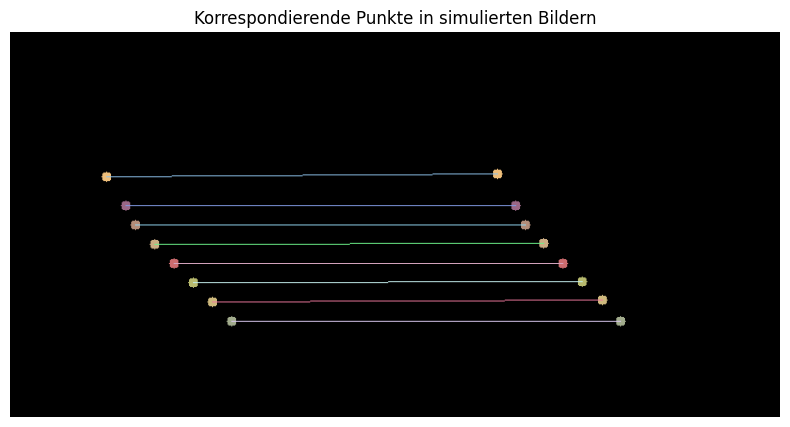

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Dummy-Bilder (schwarz, 400x400)
img1 = np.zeros((400, 400, 3), dtype=np.uint8)
img2 = np.zeros((400, 400, 3), dtype=np.uint8)

# Punkte und Linien einzeichnen
for p1, p2 in zip(pts1, pts2):
    color = tuple(np.random.randint(100, 255, 3).tolist())
    cv2.circle(img1, tuple(p1.astype(int)), 5, color, -1)
    cv2.circle(img2, tuple(p2.astype(int)), 5, color, -1)

# Bilder nebeneinander anzeigen mit Verbindungslinien
combined = np.hstack((img1, img2))

for p1, p2 in zip(pts1, pts2):
    color = tuple(np.random.randint(100, 255, 3).tolist())
    pt1 = tuple(p1.astype(int))
    pt2 = tuple((p2 + [img1.shape[1], 0]).astype(int))  # offset for second image
    cv2.line(combined, pt1, pt2, color, 1)

# Anzeige mit matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(combined[..., ::-1])  # Convert BGR to RGB
plt.title("Korrespondierende Punkte in simulierten Bildern")
plt.axis('off')
plt.show()

### Youtube Video Explanation

^

<a href="https://www.youtube.com/watch?v=hUVdUDMQ6dwWDAyDabn1Mg" target="_blank">
<img src="https://img.youtube.com/vi/dUDMQ6dwWDA/maxresdefault.jpg" alt="Uncalibrated Stereo" width="250">
</a>

<a href="https://www.youtube.com/watch?v=v30I-BqGfuI" target="_blank">
<img src="https://img.youtube.com/vi/v30I-BqGfuI/maxresdefault.jpg" alt="Problem of Uncalibrated Stereo" width="250">
</a>

<a href="https://www.youtube.com/watch?v=6kpBqfgSPRc" target="_blank">
<img src="https://img.youtube.com/vi/6kpBqfgSPRc/maxresdefault.jpg" alt="Epipolar Geometry" width="250">
</a>

<a href="https://www.youtube.com/watch?v=_rfKoEBGK7E" target="_blank">
<img src="https://img.youtube.com/vi/_rfKoEBGK7E/maxresdefault.jpg" alt="
Stereo Vision in Nature" width="250">
</a>

<a href="https://www.youtube.com/watch?v=izpYAwJ0Hlw" target="_blank">
<img src="https://img.youtube.com/vi/izpYAwJ0Hlw/maxresdefault.jpg" alt="Estimating Fundamental Matrix" width="250">
</a>

<a href="https://www.youtube.com/watch?v=erpiFudDBlg" target="_blank">
<img src="https://img.youtube.com/vi/erpiFudDBlg/maxresdefault.jpg" alt="Finding Correspondences" width="250">
</a>

<a href="https://www.youtube.com/watch?v=OYwm4VM6uNg" target="_blank">
<img src="https://img.youtube.com/vi/OYwm4VM6uNg/maxresdefault.jpg" alt="Computing Depth" width="250">
</a>

# Time of Flight

# Structured Light

<a href="https://www.youtube.com/watch?v=_Vo9Vcecwo0" target="_blank">
<img src="https://img.youtube.com/vi/_Vo9Vcecwo0/maxresdefault.jpg" alt="Simple Stereo" width="250">
</a>